In [1]:
%matplotlib inline

## Imports and project setup

In [2]:
import os
import pathlib
import urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.use("Agg")
from IPython.display import display, HTML
from scipy import signal
from scipy.interpolate import griddata
from scipy.ndimage import uniform_filter1d
import xarray as xr
import h5py

import salvus.namespace as sn
import salvus.flow.simple_config as sc
import salvus.flow.api
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
from salvus.toolbox.helpers import wavefield_output
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5

SALVUS_FLOW_SITE_NAME = os.environ.get("SALVUS_FLOW_SITE_NAME", "salome_remote_2")
PROJECT_DIR = "simulation_wavefield_custom_stf_from_mpm"
RANKS_PER_JOB = 4

def check_license_server_reachable(url="https://l.mondaic.com/licensing_server", timeout=10):
    try:
        with urllib.request.urlopen(url, timeout=timeout):
            return True
    except Exception as exc:
        raise RuntimeError(
            f"Licensing server not reachable ({url}). "
            f"Retry later or check network/VPN. Original error: {exc}"
        ) from exc

print("Imports complete.")


--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.20 seconds]
Imports complete.


## Domain setup with X buffer (supervisor fix 1)

Extend the domain so 1–2 dominant wavelengths of free elements sit before the first source, keeping sources out of the ABC near-field.

In [ ]:
vs_min          = 150.0   # slowest shear wave speed in model (m/s)
f0_dominant     = 20.0    # dominant frequency (Hz)
lambda_dominant = vs_min / f0_dominant   # = 7.5 m
x_buffer        = 3.0 * lambda_dominant  # 2 dominant wavelengths = 15 m

print(f"Dominant wavelength:          {lambda_dominant:.1f} m")
print(f"X buffer before first source: {x_buffer:.1f} m")

# MPM domain: Francis' L=40 m
mpm_x_length = 40.0
x_domain_end = x_buffer + mpm_x_length + x_buffer   # buffer on both sides

domain_2d = sn.domain.dim2.BoxDomain(
    x0=0.0, x1=x_domain_end,
    y0=0.0, y1=3.0,
)
print(f"Domain: x=[0, {x_domain_end:.1f}] m,  y=[0, 3.0] m")
print(f"Sources will span x=[{x_buffer:.1f}, {x_buffer + mpm_x_length:.1f}] m")

p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)


Dominant wavelength:          7.5 m
X buffer before first source: 15.0 m
Domain: x=[0, 70.0] m,  y=[0, 3.0] m
Sources will span x=[15.0, 55.0] m


Accordion()

## Load and inspect MPM data

Keys in NPZ: ['times', 'x_centers', 'y_centers', 'M11', 'M22', 'M12', 'dM11', 'dM12', 'dM22']
Time steps: 501,  dt=0.002000 s
Sources: 4000,  x=[0.01, 39.99] m


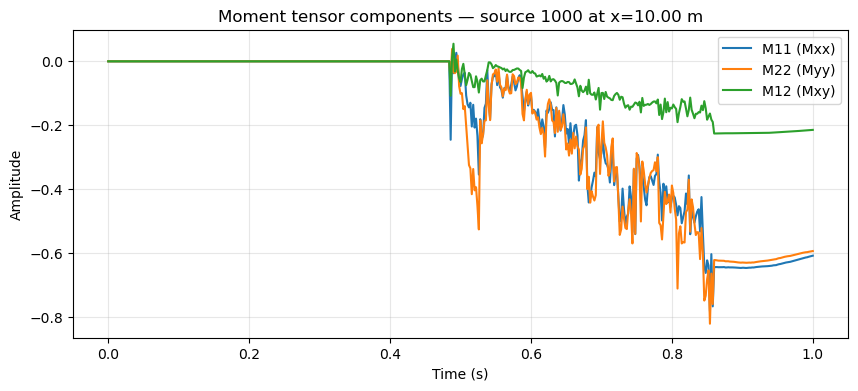

In [4]:
NPZ_FILE = 'test_mpm_mij_B-reference_tau0p3549s.npz'
data = np.load(NPZ_FILE)

print("Keys in NPZ:", data.files)

times     = data['times']
x_centers = data['x_centers']

m11 = np.squeeze(data['M11'])
m22 = np.squeeze(data['M22'])
m12 = np.squeeze(data['M12'])

print(f"Time steps: {len(times)},  dt={times[1]-times[0]:.6f} s")
print(f"Sources: {len(x_centers)},  x=[{x_centers.min():.2f}, {x_centers.max():.2f}] m")

# Plot a representative source
source_idx = min(1000, len(x_centers) - 1)

if m11.shape[0] == len(times):
    y11 = m11[:, source_idx]
    y22 = m22[:, source_idx]
    y12 = m12[:, source_idx]
else:
    y11 = m11[source_idx, :]
    y22 = m22[source_idx, :]
    y12 = m12[source_idx, :]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(times, y11, label='M11 (Mxx)', lw=1.5)
ax.plot(times, y22, label='M22 (Myy)', lw=1.5)
ax.plot(times, y12, label='M12 (Mxy)', lw=1.5)
ax.set_title(f'Moment tensor components — source {source_idx} at x={x_centers[source_idx]:.2f} m')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)
display(fig)
plt.close(fig)


## Inspect y_centers from NPZ

In [5]:
if 'y_centers' in data.files:
    y_data = data['y_centers']
    print("y_centers found in NPZ:")
    print(f"  shape: {np.atleast_1d(y_data).shape}")
    print(f"  values: {np.atleast_1d(y_data)}")
    if np.ptp(np.atleast_1d(y_data)) < 1e-6:
        print("  → All identical (flat crack / averaged over WL)")
    else:
        print(f"  → Varies by {np.ptp(np.atleast_1d(y_data))*1000:.2f} mm (crack has vertical motion)")
else:
    print("WARNING: 'y_centers' not in NPZ.")
    print("  Ask Francis to regenerate with Py saved.")
    print("  Using theoretical fallback from simulation parameters.")


y_centers found in NPZ:
  shape: (1,)
  values: [0.37500001]
  → All identical (flat crack / averaged over WL)


## Build Salvus sources from MPM data

**Supervisor fixes applied:**
- Per-source x AND y read from NPZ with validation
- Fallback to theoretical weak layer position if y_centers missing
- Amplitude taper at start and end to suppress injection noise
- Coordinate mapping: MPM frame → Salvus frame

Loading MPM moment tensor data...
Native sampling rate: 500.00 Hz  (dt=0.002000 s)
x_coords: 4000 values, range [0.005, 39.995] m
y_centers is scalar: 0.3750 m (same depth for all sources)

Coordinate mapping (MPM → Salvus):
  MPM y=0              → Salvus y=2.250 m  (base of bed layer)
  MPM WL centre y=0.375 → Salvus y=2.625 m
  X offset: +15.0 m  (buffer before first source)
Moment tensor shape: (501, 4000)  (time steps × sources)
Taper: 400 sources at each end of 4000 total

Generated 4000 sources.
  Salvus x range: [15.01, 54.99] m
  Salvus y range: [2.6250, 2.6250] m
✓ All sources inside domain with adequate boundary clearance.


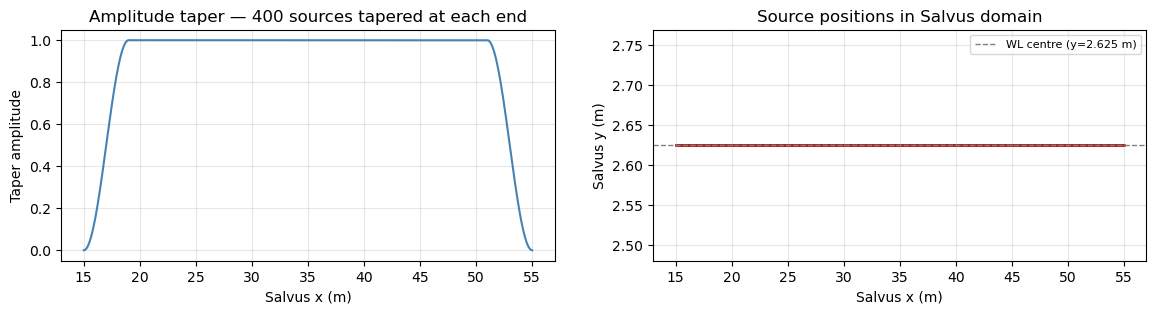

In [6]:
import numpy as np
import salvus.flow.simple_config as sc

print("Loading MPM moment tensor data...")
npz_data = np.load(NPZ_FILE)

times    = npz_data['times']
dt       = times[1] - times[0]
sampling_rate = 1.0 / dt

print(f"Native sampling rate: {sampling_rate:.2f} Hz  (dt={dt:.6f} s)")

# ── Validate x_coords ────────────────────────────────────────────────────────
if 'x_centers' not in npz_data.files:
    raise KeyError("'x_centers' missing from NPZ — ask Francis to regenerate with Px saved.")
x_coords = npz_data['x_centers']
print(f"x_coords: {len(x_coords)} values, range [{x_coords.min():.3f}, {x_coords.max():.3f}] m")

# ── Validate y_coords (supervisor fix 2) ─────────────────────────────────────
# Francis' parameters:
#   HEIGHT_BED = 0.3 m,  HEIGHT_WL = 0.15 m,  HEIGHT_SLAB = 0.3 m
#   y=0 is bottom of bed in MPM frame
MPM_HEIGHT_BED  = 0.3
MPM_HEIGHT_WL   = 0.15
MPM_HEIGHT_SLAB = 0.3
MPM_WL_CENTER_Y = MPM_HEIGHT_BED + MPM_HEIGHT_WL / 2.0   # = 0.375 m

if 'y_centers' not in npz_data.files:
    print(f"WARNING: 'y_centers' missing from NPZ.")
    print(f"  Falling back to theoretical WL centre y={MPM_WL_CENTER_Y:.4f} m")
    print(f"  → Update NPZ file (ask Francis) for accurate per-source y.")
    y_coords     = np.full_like(x_coords, MPM_WL_CENTER_Y)
    y_from_file  = False
else:
    y_coords_raw = npz_data['y_centers']
    if np.ndim(y_coords_raw) == 0 or np.atleast_1d(y_coords_raw).size == 1:
        y_val    = float(np.atleast_1d(y_coords_raw)[0])
        print(f"y_centers is scalar: {y_val:.4f} m (same depth for all sources)")
        y_coords = np.full_like(x_coords, y_val)
    else:
        y_coords = y_coords_raw
        print(f"y_coords: {len(y_coords)} values, "
              f"range [{y_coords.min():.4f}, {y_coords.max():.4f}] m")
        if np.ptp(y_coords) < 1e-6:
            print("  → All identical (flat crack — expected if averaged over WL)")
        else:
            print(f"  → Varies by {np.ptp(y_coords)*1000:.2f} mm (crack has vertical motion)")
    y_from_file = True

# ── Coordinate mapping: MPM → Salvus ─────────────────────────────────────────
# Salvus domain: y=0 (bottom) to y=3.0 m (snow-air interface)
# MPM stack from bottom: bed(0.3) + WL(0.15) + slab(0.3) = 0.75 m total
# The bottom of the MPM stack maps to y_salvus = 3.0 - 0.75 = 2.25 m
MPM_TOTAL_HEIGHT = MPM_HEIGHT_BED + MPM_HEIGHT_WL + MPM_HEIGHT_SLAB
y_salvus_base    = 3.0 - MPM_TOTAL_HEIGHT   # = 2.25 m

print(f"\nCoordinate mapping (MPM → Salvus):")
print(f"  MPM y=0              → Salvus y={y_salvus_base:.3f} m  (base of bed layer)")
print(f"  MPM WL centre y={MPM_WL_CENTER_Y:.3f} → Salvus y={y_salvus_base + MPM_WL_CENTER_Y:.3f} m")
print(f"  X offset: +{x_buffer:.1f} m  (buffer before first source)")

# ── Moment tensor components ──────────────────────────────────────────────────
m11_raw = np.squeeze(npz_data['M11'])
m22_raw = np.squeeze(npz_data['M22'])
m12_raw = np.squeeze(npz_data['M12'])

if m11_raw.shape[0] == len(times):
    m11, m22, m12 = m11_raw, m22_raw, m12_raw
else:
    m11, m22, m12 = m11_raw.T, m22_raw.T, m12_raw.T

print(f"Moment tensor shape: {m11.shape}  (time steps × sources)")

# ── Amplitude taper ───────────────────────────────────────────────────────────
n_sources = len(x_coords)
dx_src    = float(np.diff(x_coords).mean()) if n_sources > 1 else 1.0
N_taper   = max(5, int(lambda_dominant / dx_src))
N_taper   = min(N_taper, n_sources // 10)

source_taper = np.ones(n_sources)
source_taper[:N_taper]  = np.hanning(2 * N_taper)[:N_taper]   # ramp up
source_taper[-N_taper:] = np.hanning(2 * N_taper)[N_taper:]   # ramp down

print(f"Taper: {N_taper} sources at each end of {n_sources} total")

# ── Build sources ─────────────────────────────────────────────────────────────
srcs          = []
x_salvus_all  = []
y_salvus_all  = []

for i in range(n_sources):
    mxx = m11[:, i] * source_taper[i]
    myy = m22[:, i] * source_taper[i]
    mxy = m12[:, i] * source_taper[i]

    stf_array = np.column_stack((mxx, myy, mxy))

    stf = sc.stf.Custom.from_array(
        array=stf_array,
        sampling_rate_in_hertz=sampling_rate,
        start_time_in_seconds=times[0],
    )

    # Map MPM → Salvus coordinates
    x_s = x_buffer      + float(x_coords[i])
    y_s = y_salvus_base + float(y_coords[i])

    x_salvus_all.append(x_s)
    y_salvus_all.append(y_s)

    src = sc.source.cartesian.MomentTensorPoint2D(
        x=x_s, y=y_s,
        mxx=1.0, myy=1.0, mxy=1.0,
        source_time_function=stf,
    )
    srcs.append(src)

x_salvus_all = np.array(x_salvus_all)
y_salvus_all = np.array(y_salvus_all)

print(f"\nGenerated {len(srcs)} sources.")
print(f"  Salvus x range: [{x_salvus_all.min():.2f}, {x_salvus_all.max():.2f}] m")
print(f"  Salvus y range: [{y_salvus_all.min():.4f}, {y_salvus_all.max():.4f}] m")

# Sanity checks
assert x_salvus_all.min() > x_buffer * 0.5, \
    f"Sources too close to x0: min x={x_salvus_all.min():.2f} m"
assert x_salvus_all.max() < x_domain_end - x_buffer * 0.5, \
    f"Sources too close to x1: max x={x_salvus_all.max():.2f} m"
assert y_salvus_all.min() > 0.5, \
    f"Sources too close to y0 ABC: min y={y_salvus_all.min():.4f} m"
print("\u2713 All sources inside domain with adequate boundary clearance.")

# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
axes[0].plot(x_salvus_all, source_taper, color="steelblue", lw=1.5)
axes[0].set_xlabel("Salvus x (m)")
axes[0].set_ylabel("Taper amplitude")
axes[0].set_title(f"Amplitude taper — {N_taper} sources tapered at each end")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(x_salvus_all, y_salvus_all, s=1, color="firebrick", alpha=0.5)
axes[1].axhline(y_salvus_base + MPM_WL_CENTER_Y, color="gray",
                lw=1, ls="--",
                label=f"WL centre (y={y_salvus_base + MPM_WL_CENTER_Y:.3f} m)")
axes[1].set_xlabel("Salvus x (m)")
axes[1].set_ylabel("Salvus y (m)")
axes[1].set_title("Source positions in Salvus domain")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
display(fig)
plt.close(fig)


## Inspect the custom STF stored in HDF5

Source index: 1000
HDF5 file:    /tmp/salvus_internal_tmp_sbachmann/salvus.flow_custom_stf__26071610070856527b519098__2323111/custom_stf.h5
Dataset:      /stf
Shape: (501, 3),  dtype: float64
Sampling rate: 500.0 Hz,  start_time: 0.0000 s


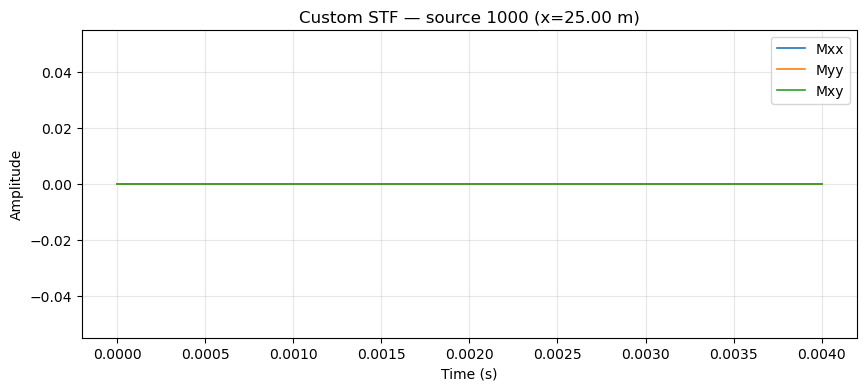

In [7]:
import h5py

check_idx = min(1000, len(srcs) - 1)

h5_path      = srcs[check_idx].source_time_function.filename
dataset_name = srcs[check_idx].source_time_function.dataset_name

print(f"Source index: {check_idx}")
print(f"HDF5 file:    {h5_path}")
print(f"Dataset:      {dataset_name}")

with h5py.File(h5_path, 'r') as f:
    dset      = f[dataset_name]
    stf_array = np.squeeze(dset[:])
    fs_stored = dset.attrs.get('sampling_rate_in_hertz', sampling_rate)
    t0_stored = dset.attrs.get('start_time_in_seconds', times[0])
    print(f"Shape: {dset.shape},  dtype: {dset.dtype}")
    print(f"Sampling rate: {fs_stored} Hz,  start_time: {t0_stored:.4f} s")

time_axis = t0_stored + np.arange(stf_array.shape[-1] if stf_array.ndim > 1
                                   else len(stf_array)) / fs_stored

fig, ax = plt.subplots(figsize=(10, 4))
if stf_array.ndim == 2:
    for comp, lbl in zip(stf_array, ['Mxx', 'Myy', 'Mxy']):
        ax.plot(time_axis, comp, lw=1.2, label=lbl)
    ax.legend()
else:
    ax.plot(time_axis, stf_array, color='crimson', lw=1.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Custom STF — source {check_idx} (x={x_salvus_all[check_idx]:.2f} m)')
ax.grid(True, alpha=0.3)
display(fig)
plt.close(fig)


## Compute max_frequency from the STF spectrum

Representative source index: 49
95th-percentile frequency:   195.6 Hz  (used for meshing)


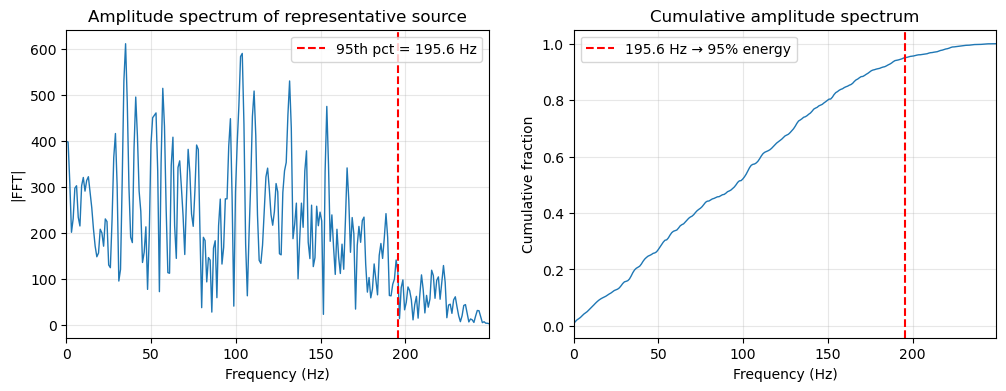

In [8]:
# Find the representative source (highest moment range)
representative_idx = np.argmax(np.max(m11, axis=0) - np.min(m11, axis=0))
raw_moment_step    = m11[:, representative_idx]
wavelet_base       = np.gradient(raw_moment_step, dt)

n_fft              = len(wavelet_base)
fft_vals           = np.fft.rfft(wavelet_base)
frequencies        = np.fft.rfftfreq(n_fft, d=dt)
amplitude_spectrum = np.abs(fft_vals)

cumulative_amplitude = np.cumsum(amplitude_spectrum)
total_amplitude      = cumulative_amplitude[-1]

percentile_95_idx  = np.where(cumulative_amplitude >= 0.95 * total_amplitude)[0][0]
max_frequency      = float(frequencies[percentile_95_idx])

print(f"Representative source index: {representative_idx}")
print(f"95th-percentile frequency:   {max_frequency:.1f} Hz  (used for meshing)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(frequencies, amplitude_spectrum, lw=1)
axes[0].axvline(max_frequency, color='r', ls='--',
                label=f'95th pct = {max_frequency:.1f} Hz')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('|FFT|')
axes[0].set_title('Amplitude spectrum of representative source')
axes[0].set_xlim(0, min(max_frequency * 2, frequencies[-1]))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(frequencies, cumulative_amplitude / total_amplitude, lw=1)
axes[1].axvline(max_frequency, color='r', ls='--',
                label=f'{max_frequency:.1f} Hz → 95% energy')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Cumulative fraction')
axes[1].set_title('Cumulative amplitude spectrum')
axes[1].set_xlim(0, min(max_frequency * 2, frequencies[-1]))
axes[1].legend()
axes[1].grid(True, alpha=0.3)
display(fig)
plt.close(fig)


## Build layered mesh

Materials matched to Francis' MPM parameters. ABC diagnostics check that sources have adequate clearance.

In [9]:
# Materials
# Note: Francis' MPM uses RHO_SLAB=250, YOUNGS_SLAB=3e6, NU=0.3
# vs_slab = sqrt(E/(2*rho*(1+nu))) ≈ 68 m/s for the MPM slab.
# We use the Salvus snow parameters here for wave propagation;
# update to MPM-matched values if you want direct comparison.
snow_mat = sn.material.from_params(rho=180.0, vp=332.0, vs=150.0)
slab_mat = sn.material.from_params(rho=180.0, vp=300.0, vs=150.0)
air_mat  = sn.material.from_params(rho=1.225, vp=300.0)

# Interfaces (Salvus y-coordinates)
# Salvus y=0 is bottom; snow-air interface is at y=3.0 m
# MPM stack: bed(0.3) + WL(0.15) + slab(0.3) = 0.75 m, placed at top of Salvus domain
interface_snow_slab = sn.layered_meshing.interface.Hyperplane.at(2.25)
interface_slab_air  = sn.layered_meshing.interface.Hyperplane.at(1.5)

model_layers = sn.layered_meshing.LayeredModel([
    snow_mat,
    interface_snow_slab,
    slab_mat,
    interface_slab_air,
    air_mat,
])

domain_2d_mesh = sn.domain.dim2.BoxDomain(
    x0=0.0, x1=x_domain_end,
    y0=0.0, y1=3.0,
)

mesh_3layer = sn.layered_meshing.mesh_from_domain(
    domain=domain_2d_mesh,
    model=model_layers,
    mesh_resolution=sn.MeshResolution(reference_frequency=max_frequency),
)
print("Mesh built successfully.")

# ABC thickness diagnostics
abc_thickness_x = lambda_dominant * 3.5   # x-sides
abc_thickness_y = 1.0                      # bottom (thin)

print(f"\nMesh domain:              x=[0, {x_domain_end:.1f}] m")
print(f"Dominant wavelength:       {lambda_dominant:.2f} m")
print(f"ABC x-sides thickness:     {abc_thickness_x:.2f} m")
print(f"ABC y-bottom thickness:    {abc_thickness_y:.2f} m")
print(f"First source at x={x_salvus_all.min():.2f} m  "
      f"(clearance from x0 ABC edge: {x_salvus_all.min() - abc_thickness_x:.2f} m)")
print(f"Last  source at x={x_salvus_all.max():.2f} m  "
      f"(clearance from x1 ABC edge: {x_domain_end - abc_thickness_x - x_salvus_all.max():.2f} m)")
print(f"Source y min = {y_salvus_all.min():.4f} m  "
      f"(clearance from y0 ABC: {y_salvus_all.min() - abc_thickness_y:.4f} m)")

if x_salvus_all.min() < abc_thickness_x + lambda_dominant:
    print("WARNING: first source within 1 wavelength of x0 ABC — near-field contamination risk")
else:
    print("\u2713 Source array has adequate clearance from x0 ABC")


Mesh built successfully.

Mesh domain:              x=[0, 70.0] m
Dominant wavelength:       7.50 m
ABC x-sides thickness:     26.25 m
ABC y-bottom thickness:    1.00 m
First source at x=15.01 m  (clearance from x0 ABC edge: -11.24 m)
Last  source at x=54.99 m  (clearance from x1 ABC edge: -11.24 m)
Source y min = 2.6250 m  (clearance from y0 ABC: 1.6250 m)


## Configure and run simulation

In [22]:
sim = sc.simulation.Waveform(mesh=mesh_3layer, sources=srcs)

sim.physics.wave_equation.end_time_in_seconds   =  float(times[-1]) + 0.5
sim.physics.wave_equation.start_time_in_seconds = float(times[0]) - 0.1

print(f"times[0] = {times[0]:.6f} s")
print(f"sim start_time = {sim.physics.wave_equation.start_time_in_seconds:.4f} s")

# The STF start must be >= sim start_time
# If times[0] < start_time_in_seconds, Salvus clips the beginning of every STF
if times[0] < sim.physics.wave_equation.start_time_in_seconds:
    print("WARNING: STF start is BEFORE simulation start — Salvus will clip the STF")
    print(f"  Set start_time_in_seconds <= {times[0]:.6f} s")

abc_sides = sc.boundary.Absorbing(
    width_in_meters=float(abc_thickness_x),
    side_sets=["x0", "x1"],
    taper_amplitude=max_frequency * 2.0,
    side_sets_are_axis_aligned=True,
)

abc_bottom = sc.boundary.Absorbing(
    width_in_meters=float(abc_thickness_y),
    side_sets=["y0"],
    taper_amplitude=max_frequency * 2.0,
    side_sets_are_axis_aligned=True,
)

sim.physics.wave_equation.boundaries = [abc_sides, abc_bottom]

sim.output.volume_data.format      = "hdf5"
sim.output.volume_data.fields      = ["displacement", "velocity"]
sim.output.volume_data.filename    = "volume_data_output.h5"
sim.output.volume_data.sampling_interval_in_time_steps = 10

moving_source_output_folder = str(
    pathlib.Path(PROJECT_DIR) / "custom_job_moving_source_all_sources"
)
print(f"Output folder: {moving_source_output_folder}")

salvus.flow.api.run(
    input_file=sim,
    site_name=SALVUS_FLOW_SITE_NAME,
    ranks=RANKS_PER_JOB,
    output_folder=moving_source_output_folder,
    overwrite=True,
    get_all=True,
)
print("Run finished successfully!")


times[0] = 0.000000 s
sim start_time = -0.1000 s
Output folder: simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources
SalvusJob `job_2607161013969286_743e02fb0c` running on `salome_remote_2` with 4 rank(s).
Site information:
  * Salvus version: 2025.1.2
  * Floating point size: 32


Solving forward problem/Computing forward wavefield:   0%|          | 0/17680 [00:00<?, ?it/s]

* Downloaded 484.0 MB of results to `simulation_wavefield_custom_stf_from_mpm/custom_job_moving_source_all_sources`.
* Total run time: 17.75 seconds.
* Pure simulation time: 11.54 seconds.
Run finished successfully!


## Load wavefield outputs

In [12]:
vol_file = pathlib.Path(moving_source_output_folder) / "volume_data_output.h5"
if not vol_file.exists():
    raise RuntimeError(f"Missing output file: {vol_file}")

vel_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "velocity", "volume")
vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo,
    points=[np.linspace(0, x_domain_end, int(x_domain_end * 4) + 1),
            np.linspace(0, 3, 101)],
)
print(f"Velocity loaded. Shape: {vel_2d_layered.dims}")
print(vel_2d_layered)

dis_wo = wavefield_output.WavefieldOutput.from_file(vol_file, "displacement", "volume")
dis_2d_layered = wavefield_output.wavefield_output_to_xarray(
    dis_wo,
    points=[np.linspace(0, x_domain_end, int(x_domain_end * 4) + 1),
            np.linspace(0, 3, 101)],
)
print(f"Displacement loaded. Shape: {dis_2d_layered.dims}")

# Spatial derivative → strain
x_dim = next(
    (d for d in ["x","X","p0","dim_0"]
     if d in dis_2d_layered.dims or d in dis_2d_layered.coords), None
)
if x_dim is None:
    raise ValueError("Cannot find x dimension in displacement field.")

dis_2d_layered_dx = dis_2d_layered.differentiate(x_dim)
print(f"Strain (d/d{x_dim}) computed.")

# Resolve dim names for downstream cells
coords_set = set(vel_2d_layered.coords)
dims_set   = set(vel_2d_layered.dims)
x_name = next((n for n in ["x","X","p0","dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y","Y","p1","dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t","time"]           if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c","component"]      if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index","event","source"] if n in coords_set or n in dims_set), None)
print(f"Dims resolved: x={x_name}, y={y_name}, t={t_name}, c={c_name}, event={e_name}")


Finding enclosing elements (pass 1 of auto):   0%|          | 0/28381 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/14050 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/14050 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/14050 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/14050 [00:00<?, ?it/s]

...

Finding enclosing elements (pass 5 of auto):   0%|          | 0/14050 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/14050 [00:00<?, ?it/s]

[2026-07-16 10:08:40,578] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 14050 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/4 [00:00<?, ?it/s]

Displacement loaded. Shape: ('t', 'c', 'x', 'y')
Strain (d/dx) computed.
Dims resolved: x=x, y=y, t=t, c=c, event=None


## Helper functions for plotting

In [13]:
def _extract_section(data_array, receiver_y, component_index=0):
    """Extract a (t, x) section at a given y depth and component."""
    coords_set = set(data_array.coords)
    dims_set   = set(data_array.dims)
    _x = next((n for n in ["x","X","p0","dim_0"] if n in coords_set or n in dims_set), None)
    _y = next((n for n in ["y","Y","p1","dim_1"] if n in coords_set or n in dims_set), None)
    _t = next((n for n in ["t","time"]           if n in coords_set or n in dims_set), None)
    _c = next((n for n in ["c","component"]      if n in coords_set or n in dims_set), None)
    _e = next((n for n in ["event_index","event","source"] if n in coords_set or n in dims_set), None)

    if _c and (_c in data_array.dims or _c in data_array.coords):
        sec = data_array.isel({_c: component_index})
    else:
        sec = data_array

    sec = sec.sel({_y: receiver_y}, method="nearest")
    if _e and _e in sec.dims:
        sec = sec.mean(dim=_e)
    sec = sec.transpose(_t, _x)
    return {"x_vals": sec[_x].values, "t_vals": sec[_t].values, "data": sec.values}


def apply_das_gauge(strain_2d_xarray, gauge_length_m, x_name_override=None):
    """
    Simulate DAS measurement by convolving strain along x
    with a normalized boxcar of length gauge_length_m.
    """
    _x = x_name_override or next(
        (n for n in ["x","X","p0","dim_0"]
         if n in strain_2d_xarray.dims or n in strain_2d_xarray.coords), None
    )
    x_vals = strain_2d_xarray[_x].values
    dx     = float(np.diff(x_vals).mean())
    n_gl   = max(1, int(round(gauge_length_m / dx)))
    data_f = uniform_filter1d(strain_2d_xarray.values, size=n_gl, axis=1, mode="nearest")
    return xr.DataArray(data_f, dims=strain_2d_xarray.dims, coords=strain_2d_xarray.coords)


def compute_das_section(dis_2d, receiver_y, gauge_length_m,
                        component_index=0, take_time_derivative=True):
    """Full DAS pipeline: displacement → strain → gauge-length average → strain rate."""
    coords_set = set(dis_2d.coords)
    dims_set   = set(dis_2d.dims)
    _x = next((n for n in ["x","X","p0","dim_0"] if n in coords_set or n in dims_set), None)
    _y = next((n for n in ["y","Y","p1","dim_1"] if n in coords_set or n in dims_set), None)
    _t = next((n for n in ["t","time"]           if n in coords_set or n in dims_set), None)
    _c = next((n for n in ["c","component"]      if n in coords_set or n in dims_set), None)
    _e = next((n for n in ["event_index","event","source"] if n in coords_set or n in dims_set), None)

    if _c and (_c in dis_2d.dims or _c in dis_2d.coords):
        sec = dis_2d.isel({_c: component_index})
    else:
        sec = dis_2d

    sec = sec.sel({_y: receiver_y}, method="nearest")
    if _e and _e in sec.dims:
        sec = sec.mean(dim=_e)
    sec = sec.transpose(_t, _x)

    strain     = sec.differentiate(_x)
    strain_das = apply_das_gauge(strain, gauge_length_m, x_name_override=_x)
    output     = strain_das.differentiate(_t) if take_time_derivative else strain_das

    return {"x_vals": output[_x].values, "t_vals": output[_t].values, "data": output.values}


def plot_waterfall(ax, x_vals, t_vals, data, title="", xlabel="Distance (m)",
                   ylabel="Time (s)", cmap="RdBu_r", percentile=95):
    valid = data[np.isfinite(data)]
    vmax  = np.percentile(np.abs(valid), percentile) if valid.size else 1.0
    im    = ax.pcolormesh(x_vals, t_vals, data, shading="gouraud",
                          cmap=cmap, vmin=-vmax, vmax=vmax)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=9)
    return im

print("Helper functions defined.")


Helper functions defined.


## Waterfall plots — velocity, strain, and DAS synthetic

Using dimensions: {'x': 'x', 'y': 'y', 't': 't', 'c': 'c', 'event': None}
t range: -0.1 -> 1.5
vx shape: (1769, 281)
vy shape: (1769, 281)


/tmp/ipykernel_2323111/75978856.py:60: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vx = axes[0].pcolormesh(
/tmp/ipykernel_2323111/75978856.py:82: UserWarning: shading value 'none' not in list of valid values ['gouraud', 'nearest', 'flat', 'auto']. Setting shading='auto'.
  im_vy = axes[1].pcolormesh(


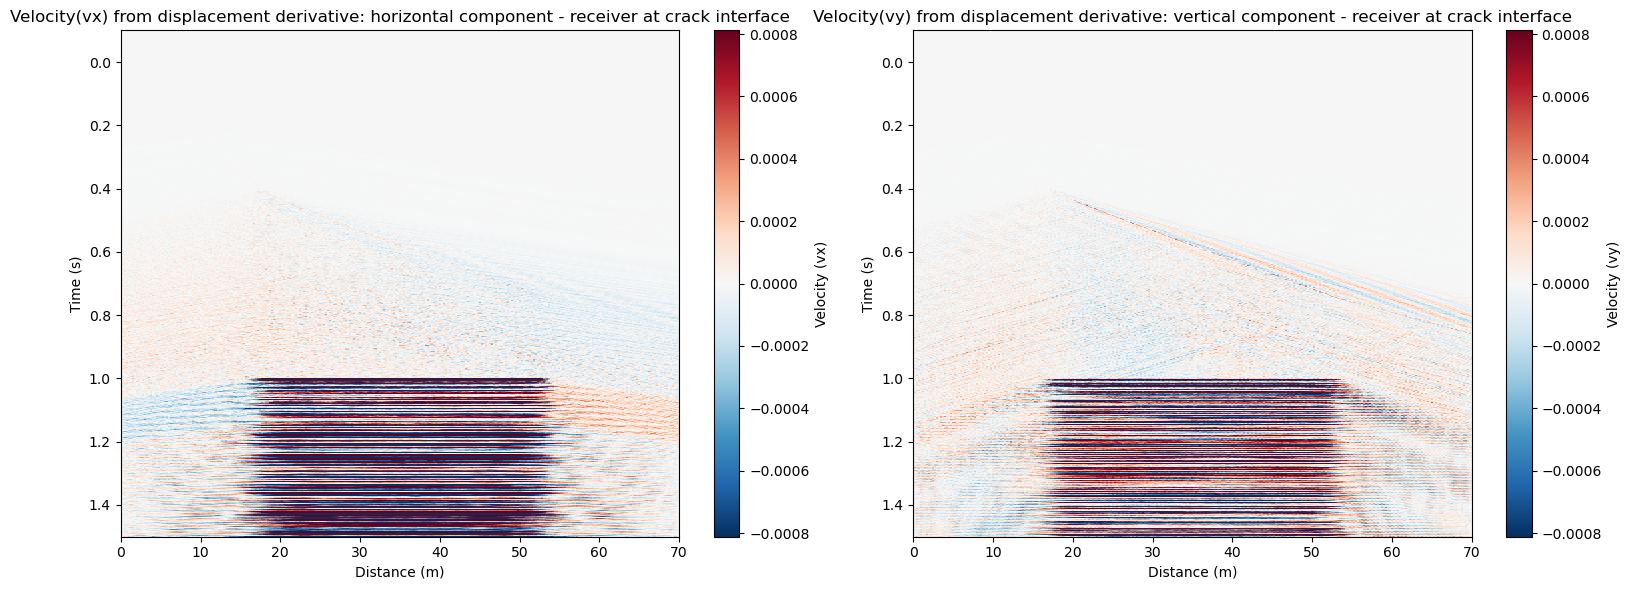

In [20]:
# instead of velocity: temporal derivative of displacement to get velocity
dis_2d_layered_dt = dis_2d_layered.differentiate(t_name)

# plotting displacement temporal derivative (velocity)
# Force inline display in case backend was set to Agg earlier
import matplotlib.pyplot as plt
from IPython.display import display

# Define receiver line 
y_surface = 2.625 # 

# dis_2d_layered is already an xarray built from all events.
# Use direct selection instead of calling wavefield_output_to_xarray again.
    
# Resolve coordinate / dimension names robustly.
coords_set = set(dis_2d_layered_dt.coords)
dims_set = set(dis_2d_layered_dt.dims)

x_name = next((n for n in ["x", "X", "p0", "dim_0"] if n in coords_set or n in dims_set), None)
y_name = next((n for n in ["y", "Y", "p1", "dim_1"] if n in coords_set or n in dims_set), None)
t_name = next((n for n in ["t", "time"] if n in coords_set or n in dims_set), None)
c_name = next((n for n in ["c", "component"] if n in coords_set or n in dims_set), None)
e_name = next((n for n in ["event_index", "event", "source"] if n in coords_set or n in dims_set), None)

if x_name is None or y_name is None or t_name is None or c_name is None:
    raise ValueError(f"Could not resolve required dimensions. Found dims={dis_2d_layered_dt.dims}, coords={list(dis_2d_layered_dt.coords)}")

# Select both components at y receiver line
sg_vx = dis_2d_layered_dt.isel({c_name: 0}).sel({y_name: y_surface}, method="nearest")
sg_vy = dis_2d_layered_dt.isel({c_name: 1}).sel({y_name: y_surface}, method="nearest")

# Keep all moving-source events by reducing event dimension to a single stacked section.
if e_name is not None and e_name in sg_vx.dims:
    sg_vx_plot = sg_vx.mean(dim=e_name)
    sg_vy_plot = sg_vy.mean(dim=e_name)
else:
    sg_vx_plot = sg_vx
    sg_vy_plot = sg_vy

# Ensure plotting order is (time, x)
sg_vx_plot = sg_vx_plot.transpose(t_name, x_name)
sg_vy_plot = sg_vy_plot.transpose(t_name, x_name)

t_vals = sg_vx_plot[t_name].values
x_line = sg_vx_plot[x_name].values
data_vx = sg_vx_plot.values
data_vy = sg_vy_plot.values

print("Using dimensions:", {"x": x_name, "y": y_name, "t": t_name, "c": c_name, "event": e_name})
print("t range:", t_vals[0], "->", t_vals[-1])
print("vx shape:", data_vx.shape)
print("vy shape:", data_vy.shape)

# Clip colorscale (use same scale for both for comparison)
vmax = np.percentile(np.abs([data_vx, data_vy]), 95)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot vx (horizontal component)
im_vx = axes[0].pcolormesh(
    x_line,
    t_vals,
    data_vx,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].invert_yaxis()

# Mark all moving source positions
# for x_src in x_positions:
#     axes[0].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[0].set_xlabel("Distance (m)")
axes[0].set_ylabel("Time (s)")
axes[0].set_xlim(0, 70)
axes[0].set_title("Velocity(vx) from displacement derivative: horizontal component - receiver at crack interface")
plt.colorbar(im_vx, ax=axes[0], label="Velocity (vx)")

# Plot vy (vertical component)
im_vy = axes[1].pcolormesh(
    x_line,
    t_vals,
    data_vy,
    shading="none",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].invert_yaxis()

# # Mark all moving source positions
# for x_src in x_positions:
#     axes[1].axvline(x=x_src, color="teal", lw=0.5, linestyle="--", alpha=0.35)

axes[1].set_xlabel("Distance (m)")
axes[1].set_ylabel("Time (s)")
axes[1].set_xlim(0, 70)
axes[1].set_title("Velocity(vy) from displacement derivative: vertical component - receiver at crack interface")
plt.colorbar(im_vy, ax=axes[1], label="Velocity (vy)")

plt.tight_layout()

# Display explicitly in notebook output
display(fig)
plt.close(fig)

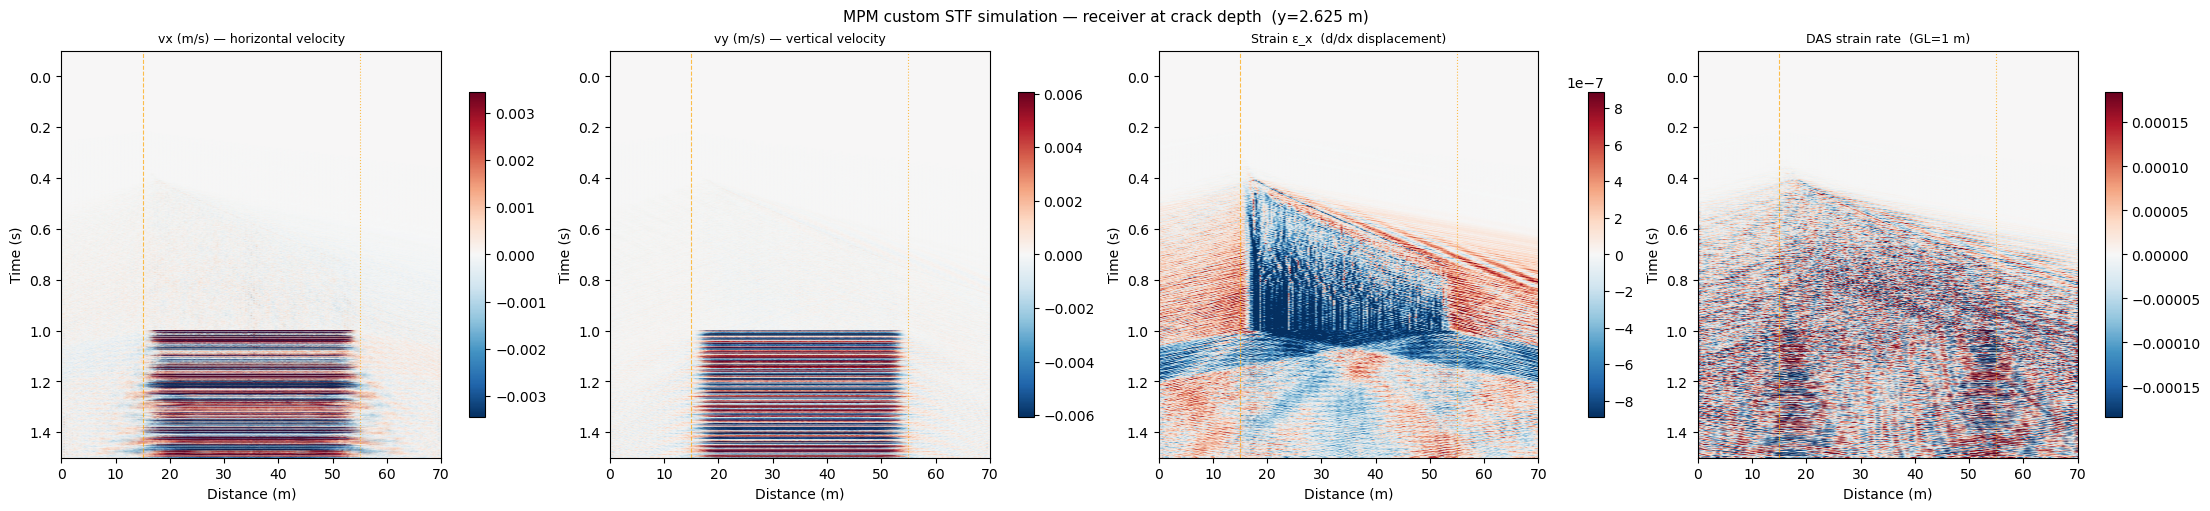

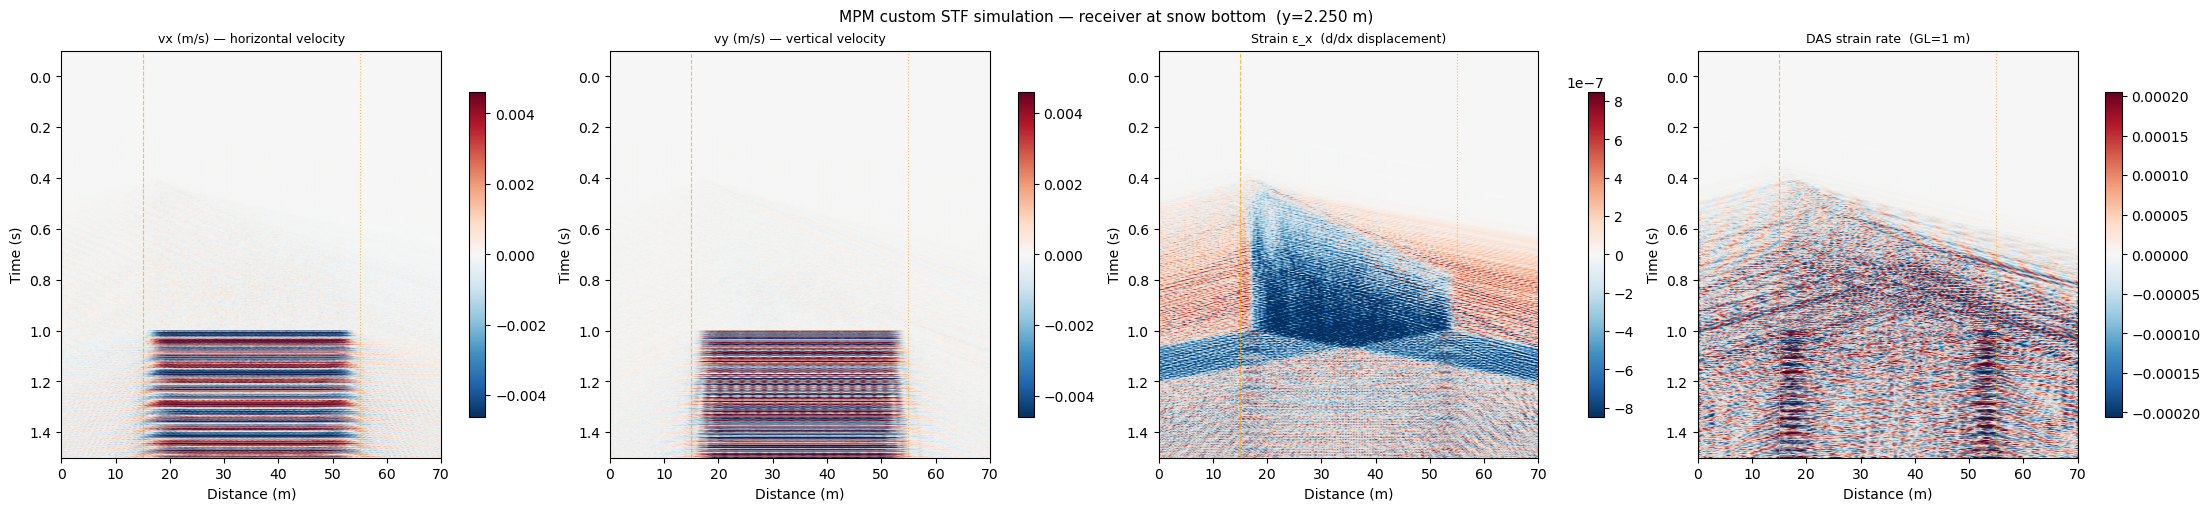

In [14]:
y_crack   = float(y_salvus_all.mean())   # receiver at crack depth
y_surface = 2.25                          # receiver at snow bottom
gauge_length_m = 1.0                      # DAS gauge length (m)

for recv_y, recv_label in [(y_crack, "crack depth"), (y_surface, "snow bottom")]:
    vx_sec  = _extract_section(vel_2d_layered,    recv_y, component_index=0)
    vy_sec  = _extract_section(vel_2d_layered,    recv_y, component_index=1)
    str_sec = _extract_section(dis_2d_layered_dx, recv_y, component_index=0)
    das_sec = compute_das_section(dis_2d_layered, recv_y,
                                  gauge_length_m=gauge_length_m,
                                  component_index=0,
                                  take_time_derivative=True)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5), constrained_layout=True)
    col_data = [vx_sec, vy_sec, str_sec, das_sec]
    col_titles = [
        "vx (m/s) — horizontal velocity",
        "vy (m/s) — vertical velocity",
        f"Strain ε_x  (d/dx displacement)",
        f"DAS strain rate  (GL={gauge_length_m:.0f} m)",
    ]

    for ax, sec, title in zip(axes, col_data, col_titles):
        im = plot_waterfall(ax, sec["x_vals"], sec["t_vals"], sec["data"],
                            title=title)
        # Mark source array extent
        ax.axvline(x_salvus_all.min(), color="orange", lw=0.8, ls="--", alpha=0.7)
        ax.axvline(x_salvus_all.max(), color="orange", lw=0.8, ls=":",  alpha=0.7)
        plt.colorbar(im, ax=ax, shrink=0.8)

    fig.suptitle(f"MPM custom STF simulation — receiver at {recv_label}  (y={recv_y:.3f} m)",
                 fontsize=11)
    display(fig)
    plt.close(fig)


## Strain rate and strain at two receiver depths

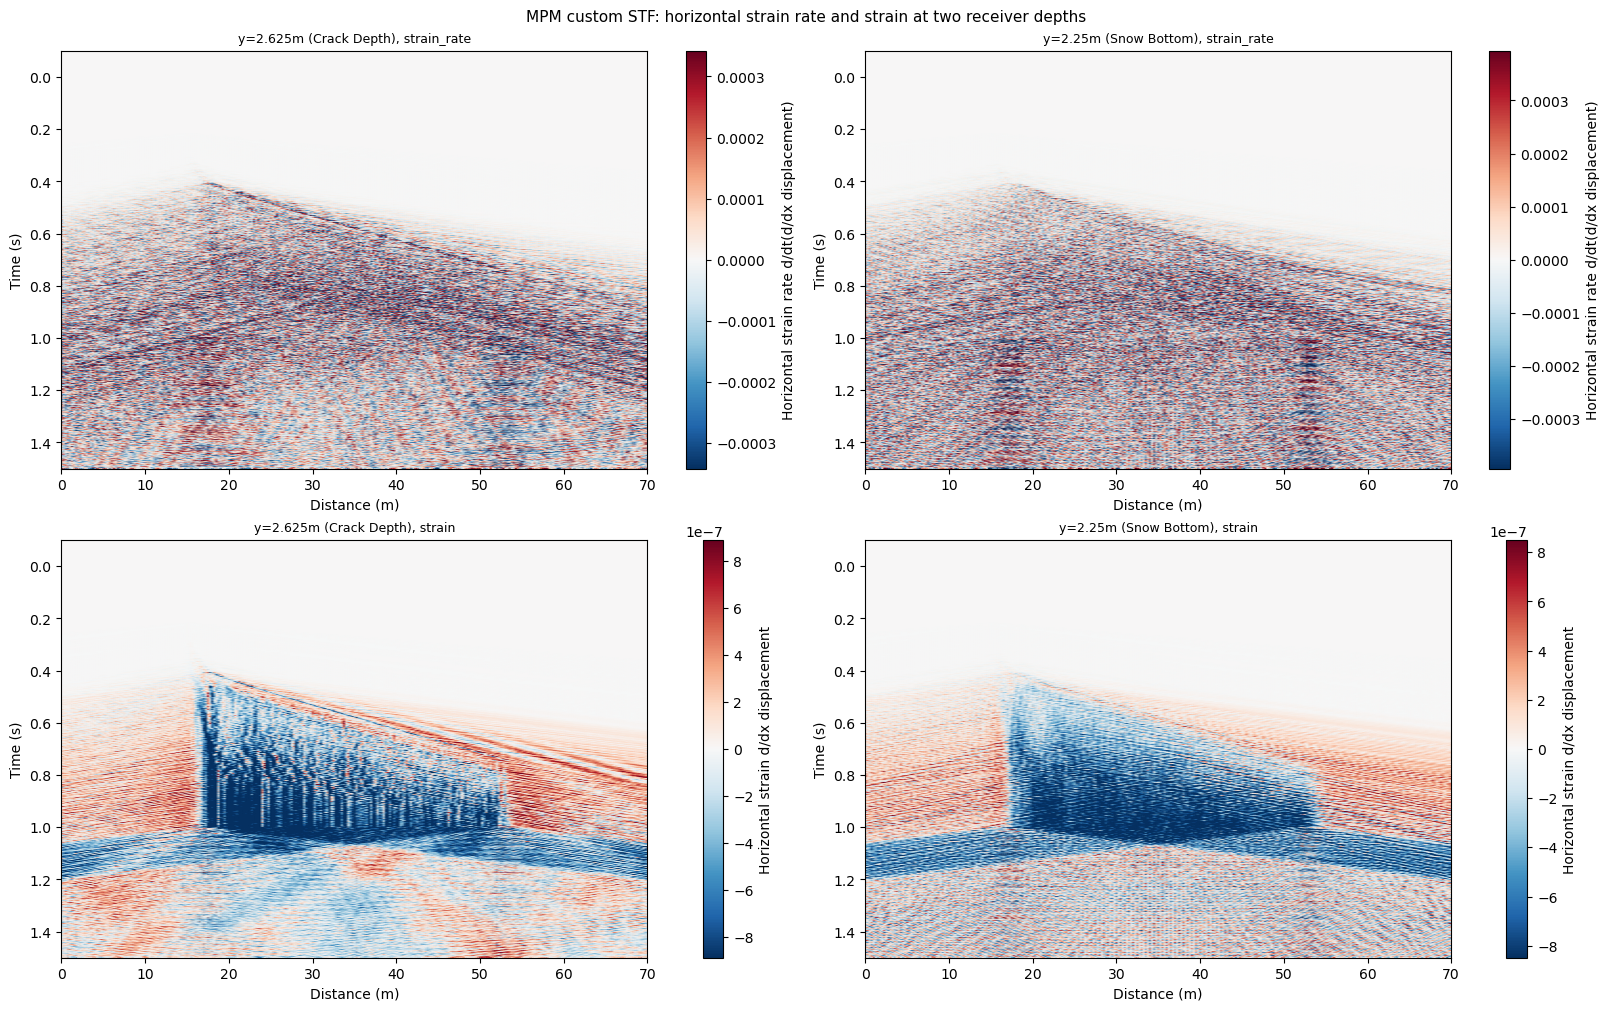

In [15]:
y_recv_1 = float(y_salvus_all.mean())   # crack depth
y_recv_2 = 2.25                          # snow bottom

fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)

for col, (recv_y, label) in enumerate([(y_recv_1, f"y={y_recv_1:.3f}m (Crack Depth)"),
                                        (y_recv_2, f"y={y_recv_2:.2f}m (Snow Bottom)")]):
    # strain rate = d/dt (d/dx displacement)
    strain_sec = _extract_section(dis_2d_layered_dx, recv_y, component_index=0)
    t_name_loc = t_name  # from Cell 10

    # time derivative via xarray
    da_strain = dis_2d_layered_dx.isel({c_name: 0}).sel({y_name: recv_y}, method="nearest")
    if e_name and e_name in da_strain.dims:
        da_strain = da_strain.mean(dim=e_name)
    da_strain = da_strain.transpose(t_name, x_name)
    da_strain_rate = da_strain.differentiate(t_name)
    strain_rate_data = {
        "x_vals": da_strain_rate[x_name].values,
        "t_vals": da_strain_rate[t_name].values,
        "data":   da_strain_rate.values,
    }

    im0 = plot_waterfall(axes[0, col], strain_rate_data["x_vals"],
                         strain_rate_data["t_vals"], strain_rate_data["data"],
                         title=f"{label}, strain_rate")
    plt.colorbar(im0, ax=axes[0, col],
                 label="Horizontal strain rate d/dt(d/dx displacement)")

    im1 = plot_waterfall(axes[1, col], strain_sec["x_vals"],
                         strain_sec["t_vals"], strain_sec["data"],
                         title=f"{label}, strain")
    plt.colorbar(im1, ax=axes[1, col],
                 label="Horizontal strain d/dx displacement")

fig.suptitle("MPM custom STF: horizontal strain rate and strain at two receiver depths",
             fontsize=11)
display(fig)
plt.close(fig)


## f-k spectrum

Estimated rupture speed: 40.0 m/s


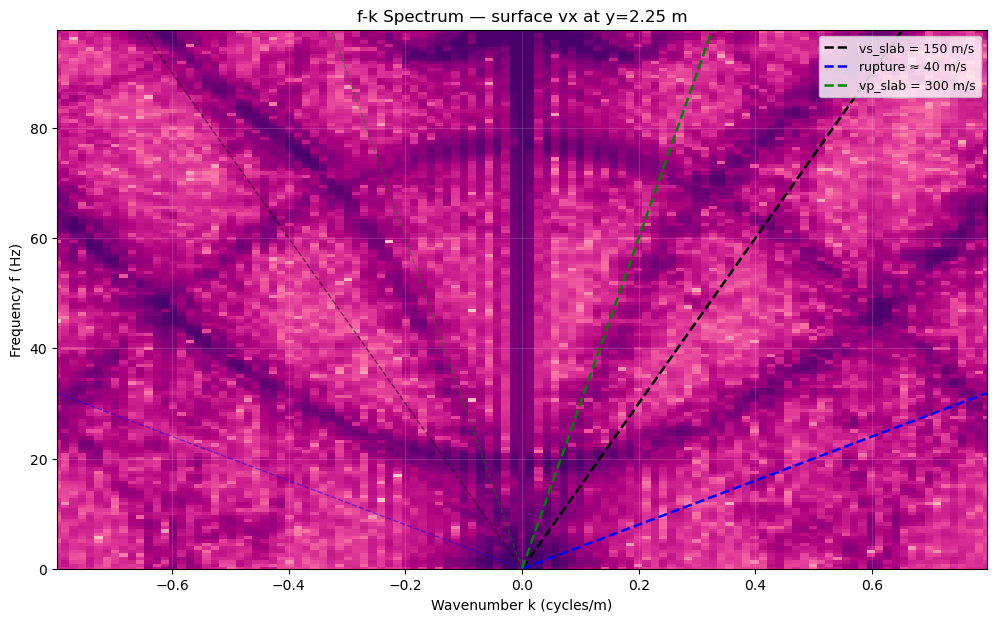

In [16]:
target_vprop = float(np.ptp(x_salvus_all)) / float(np.ptp(times)) \
               if np.ptp(times) > 0 else 100.0
print(f"Estimated rupture speed: {target_vprop:.1f} m/s")

y_recv_fk = 2.25
sg = vel_2d_layered.sel({y_name: y_recv_fk}, method="nearest").isel({c_name: 0})
t_vals_fk = sg[t_name].values
x_vals_fk = sg[x_name].values
data_fk   = sg.values
if data_fk.shape[0] == len(x_vals_fk):
    data_fk = data_fk.T

nt, nx = data_fk.shape
dt_fk   = float(np.nanmedian(np.diff(t_vals_fk)))
dx_fk   = float(np.nanmedian(np.diff(x_vals_fk)))

taper_t      = np.hanning(nt)
taper_x      = np.hanning(nx)

# Per-trace normalisation before tapering (prevents early-cluster dominance)
std_per_trace = np.std(data_fk, axis=0, keepdims=True)
std_per_trace[std_per_trace < 1e-20] = 1.0
data_norm = data_fk / std_per_trace

data_tapered = data_norm * taper_t[:, None] * taper_x[None, :]

fk    = np.fft.fftshift(np.fft.fft2(data_tapered))
freqs = np.fft.fftshift(np.fft.fftfreq(nt, dt_fk))
wns   = np.fft.fftshift(np.fft.fftfreq(nx, dx_fk))

f_pos_mask = freqs >= 0
fk_pos     = fk[f_pos_mask, :]
f_plot     = freqs[f_pos_mask]

velocities = {
    f"vs_slab = {vs_min:.0f} m/s": vs_min,
    f"rupture ≈ {target_vprop:.0f} m/s": target_vprop,
    "vp_slab = 300 m/s": 300.0,
}
colors = ["black", "blue", "green"]

fig, ax = plt.subplots(figsize=(12, 7))
pk     = np.log10(np.abs(fk_pos) + 1e-10)
vmax_pk = np.percentile(pk, 99)
vmin_pk = vmax_pk - 4.5

WNS, FREQS = np.meshgrid(wns, f_plot)
ax.pcolormesh(WNS, FREQS, pk, shading="nearest", cmap="RdPu",
              vmin=vmin_pk, vmax=vmax_pk)

k_max = wns.max()
for (label, v), col in zip(velocities.items(), colors):
    k_r = f_plot / v
    m_r = np.abs(k_r) <= k_max
    ax.plot( k_r[m_r], f_plot[m_r], color=col, lw=1.8, ls="--", label=label)
    ax.plot(-k_r[m_r], f_plot[m_r], color=col, lw=1.0, ls="--", alpha=0.5)

ax.set_xlim(-k_max * 0.4, k_max * 0.4)
ax.set_ylim(0, min(max_frequency * 0.5, f_plot.max()))
ax.set_xlabel("Wavenumber k (cycles/m)")
ax.set_ylabel("Frequency f (Hz)")
ax.set_title(f"f-k Spectrum — surface vx at y={y_recv_fk} m")
ax.legend(fontsize=9, loc="upper right")
ax.grid(True, alpha=0.15, color="white")
display(fig)
plt.close(fig)


## DAS synthetic waterfall (gauge-length convolution)

/home/sbachmann/miniforge3/envs/salvus/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


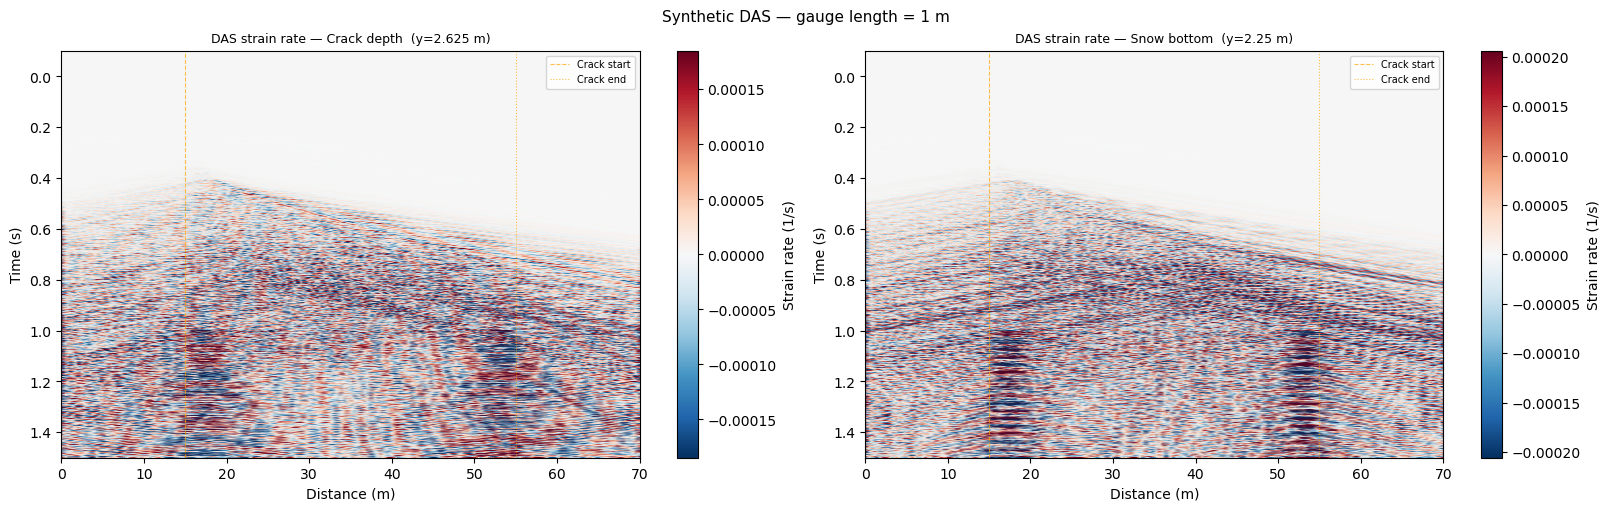

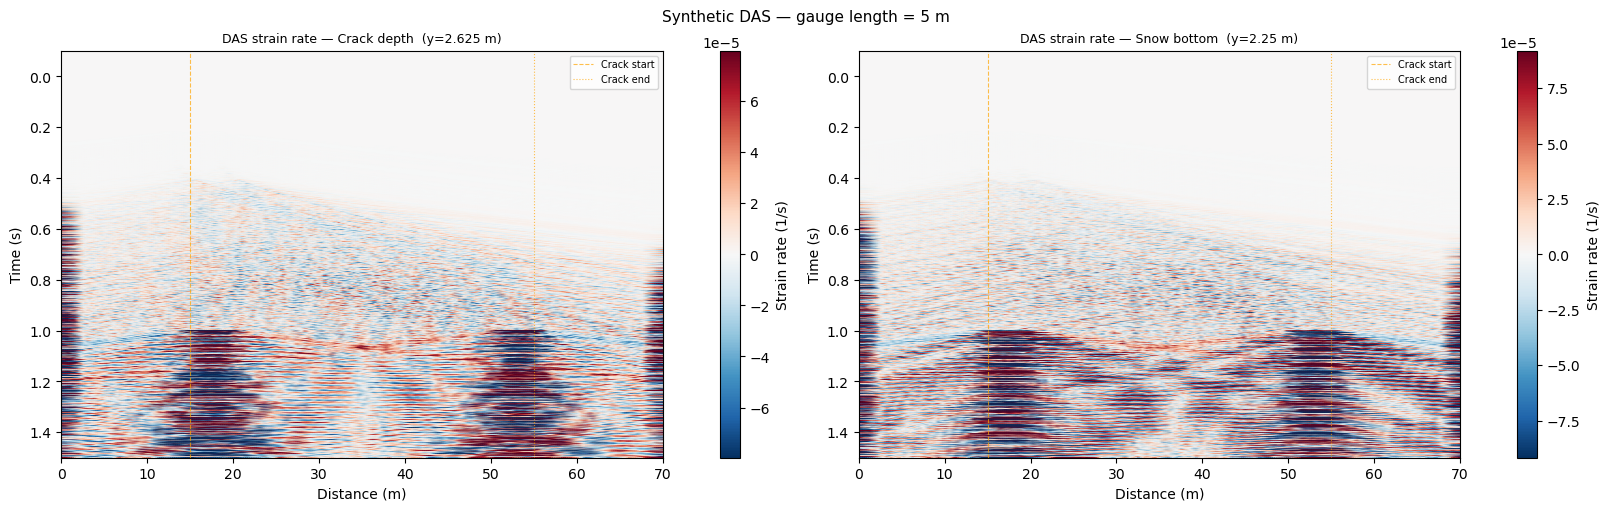

In [17]:
for gauge_length_m in [1.0, 5.0]:
    das_crack   = compute_das_section(dis_2d_layered, float(y_salvus_all.mean()),
                                      gauge_length_m, component_index=0,
                                      take_time_derivative=True)
    das_surface = compute_das_section(dis_2d_layered, 2.25,
                                      gauge_length_m, component_index=0,
                                      take_time_derivative=True)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
    for ax, sec, label in zip(
        axes,
        [das_crack, das_surface],
        [f"Crack depth  (y={y_salvus_all.mean():.3f} m)",
         f"Snow bottom  (y=2.25 m)"],
    ):
        im = plot_waterfall(ax, sec["x_vals"], sec["t_vals"], sec["data"],
                            title=f"DAS strain rate — {label}")
        ax.axvline(x_salvus_all.min(), color="orange", lw=0.8, ls="--", alpha=0.7,
                   label="Crack start")
        ax.axvline(x_salvus_all.max(), color="orange", lw=0.8, ls=":",  alpha=0.7,
                   label="Crack end")
        ax.legend(fontsize=7)
        plt.colorbar(im, ax=ax, label="Strain rate (1/s)")

    fig.suptitle(f"Synthetic DAS — gauge length = {gauge_length_m:.0f} m", fontsize=11)
    display(fig)
    plt.close(fig)
